# AI 기술면접 질문 생성기 (LoRA, 양자화 없음)

이 노트북은 **Qwen/Qwen3-1.7B** 모델을 양자화하지 않고 `bf16`으로 불러온 뒤, **LoRA 어댑터만 학습**해 지원자의 직무와 경험에 맞는 심층 기술면접 질문 3개를 생성하는 실습입니다.

핵심 흐름은 다음과 같습니다.

1. 파인튜닝 전 기본 모델이 생성하는 면접 질문을 확인합니다.
2. 직무·경험과 모범 면접 질문으로 구성된 31개 데이터를 `prompt` / `completion` 형태로 변환합니다.
3. 원본 모델 가중치는 고정하고 LoRA 어댑터만 학습합니다.
4. 학습 데이터와 직접 겹치지 않는 샘플로 파인튜닝 전/후 결과를 비교합니다.
5. 학습된 LoRA 어댑터만 파일로 저장합니다.

> 이 노트북은 **QLoRA가 아닙니다.** 모델 가중치를 4bit로 불러오지 않습니다. 다만 학습 시 VRAM을 아끼기 위해 optimizer는 `paged_adamw_8bit`를 사용합니다.

## 5-2 QLoRA와 비교

같은 모델, 데이터 전처리, LoRA 설정, 80 step 학습, EOS 토큰과 생성 옵션을 사용합니다. 베이스 모델은 BF16(미지원 시 FP16)으로 로드하며, 5-2는 NF4 4bit로 로드합니다.

다른 GPU 노트북 커널을 종료하고 해당 커널을 재시작한 뒤 위에서부터 실행하세요. 학습 실행 셀은 한 번만 실행합니다. 최대 allocated VRAM, 학습 시간, loss 추세와 동일한 테스트 질문의 답변을 비교하세요.

train_loss는 전체 학습 평균이며 마지막 step의 loss나 검증 성능이 아닙니다. allocated는 PyTorch 텐서 메모리, reserved는 캐시를 포함한 확보 메모리로 GPU 전체 사용량과 다릅니다.


In [1]:
import os
import warnings
import logging

# 1. 파이썬 기본 경고 무시
warnings.filterwarnings("ignore")

# 2. 시스템 환경변수를 통한 Hugging Face 및 커널 로그 제어 (0=ALL, 1=INFO, 2=WARNING, 3=ERROR)
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["LOGGERS_LEVEL"] = "ERROR"

# 3. transformers 자체 라이브러리 로그 레벨을 ERROR로 설정
from transformers import logging as transformers_logging
transformers_logging.set_verbosity_error()

## 0. 환경 확인

먼저 Python, PyTorch, CUDA, GPU, VRAM 상태를 확인합니다. 이 실습은 **Python 3.12 + JupyterLab** 환경을 기준으로 작성되었습니다.

- NVIDIA GPU가 정상적으로 인식되어야 합니다.
- 이 노트북의 기록된 실행 결과는 12GB VRAM GPU를 기준으로 합니다.
- VRAM이 부족하면 뒤쪽 학습 설정에서 `max_length`나 LoRA의 `r` 값을 줄이세요.


In [2]:
import os
import gc
import platform
from contextlib import nullcontext

import torch

print(f"Python 버전: {platform.python_version()}")
print(f"PyTorch 버전: {torch.__version__}")
print(f"CUDA 사용 가능: {torch.cuda.is_available()}")

if not torch.cuda.is_available():
    raise RuntimeError("이 노트북은 LoRA CUDA GPU 학습용입니다. NVIDIA GPU/CUDA 환경을 먼저 확인하세요.")

GPU_NAME = torch.cuda.get_device_name(0)
TOTAL_VRAM_GB = torch.cuda.get_device_properties(0).total_memory / (1024**3)
BF16_OK = torch.cuda.is_bf16_supported()
COMPUTE_DTYPE = torch.bfloat16 if BF16_OK else torch.float16

print(f"GPU 이름: {GPU_NAME}")
print(f"총 VRAM: {TOTAL_VRAM_GB:.1f} GB")
print(f"BF16 지원: {BF16_OK}")
print(f"학습 compute dtype: {COMPUTE_DTYPE}")


Python 버전: 3.12.13
PyTorch 버전: 2.10.0+cu128
CUDA 사용 가능: True
GPU 이름: NVIDIA GeForce RTX 4060 Laptop GPU
총 VRAM: 8.0 GB
BF16 지원: True
학습 compute dtype: torch.bfloat16


## 1. 패키지 설치 및 버전 확인

처음 실행하는 환경이라면 필요한 패키지를 한 번만 설치합니다. 이미 설치되어 있다면 설치 셀은 건너뛰고, 바로 버전 확인 셀만 실행해도 됩니다.

이 노트북에서 사용하는 주요 패키지는 다음과 같습니다.

- `transformers`: Qwen 모델과 tokenizer 로드
- `peft`: LoRA 어댑터 구성 및 저장
- `trl`: `SFTTrainer`를 이용한 지도 미세조정
- `bitsandbytes`: `paged_adamw_8bit` optimizer 사용
- `datasets`: 학습 데이터셋 구성

> 여기서 `bitsandbytes`를 쓰지만, 이 노트북은 모델을 4bit로 양자화하지 않습니다. `bitsandbytes`는 optimizer 메모리 절약을 위해 사용됩니다.


In [3]:
import datasets

In [4]:
import transformers, peft, trl, bitsandbytes, accelerate

Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0+cu128).


In [5]:
print("transformers :", transformers.__version__)
print("peft         :", peft.__version__)
print("trl          :", trl.__version__)
print("bitsandbytes :", bitsandbytes.__version__)
print("accelerate   :", accelerate.__version__)
print("datasets     :", datasets.__version__)


transformers : 5.5.0
peft         : 0.19.1
trl          : 0.24.0
bitsandbytes : 0.49.2
accelerate   : 1.14.0
datasets     : 4.3.0


## 2. 모델 로드 (양자화 없음 · BF16/FP16)

5-2와 같은 모델과 tokenizer, EOS 토큰을 사용합니다. 베이스 모델은 COMPUTE_DTYPE으로 로드하며 BF16 미지원 GPU에서는 FP16을 사용합니다.


In [6]:
from huggingface_hub import login
from dotenv import load_dotenv
import os

# .env 파일 로드
load_dotenv(override=True)

HF_TOKEN = os.getenv("HF_TOKEN")
login(token=HF_TOKEN)

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


In [7]:
from transformers import AutoModelForCausalLM, AutoTokenizer

MODEL_ID = "Qwen/Qwen3-1.7B"  # 예: "Qwen/Qwen3-4B-Instruct-2507"

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, trust_remote_code=True)

# Qwen chat template의 assistant 종료 토큰은 보통 <|im_end|>입니다.
# SFTConfig에 eos_token으로 명시하면 학습/생성 종료가 더 안정적입니다.
vocab = tokenizer.get_vocab()
EOS_TOKEN = "<|im_end|>" if "<|im_end|>" in vocab else tokenizer.eos_token
if EOS_TOKEN is None:
    raise ValueError("tokenizer.eos_token을 찾지 못했습니다. 모델 토크나이저를 확인하세요.")

tokenizer.eos_token = EOS_TOKEN
if tokenizer.pad_token is None:
    tokenizer.pad_token = EOS_TOKEN

def load_causal_lm(model_id: str):
    kwargs = dict(
        device_map={"": 0},
        trust_remote_code=True,
    )
    # transformers 버전에 따라 dtype / torch_dtype 인자명이 다를 수 있어 fallback을 둡니다.
    try:
        return AutoModelForCausalLM.from_pretrained(model_id, dtype=COMPUTE_DTYPE, **kwargs)
    except TypeError:
        return AutoModelForCausalLM.from_pretrained(model_id, torch_dtype=COMPUTE_DTYPE, **kwargs)

model = load_causal_lm(MODEL_ID)
model.config.use_cache = False

print("모델 로드 완료 (LoRA, 양자화 없음)")
print("EOS_TOKEN:", repr(EOS_TOKEN), "id=", tokenizer.eos_token_id)
print("PAD_TOKEN:", repr(tokenizer.pad_token), "id=", tokenizer.pad_token_id)
print(f"현재 GPU 메모리 사용량: {torch.cuda.memory_allocated()/1024**3:.2f} GB")


Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

모델 로드 완료 (LoRA, 양자화 없음)
EOS_TOKEN: '<|im_end|>' id= 151645
PAD_TOKEN: '<|endoftext|>' id= 151643
현재 GPU 메모리 사용량: 3.20 GB


## 3. 공통 유틸리티

핵심은 `ensure_lora_trainable()`입니다. 사용자가 겪은 `LoRA params는 있는데 Trainable LoRA params가 0개`인 상태를 여기서 바로 잡거나, 잡히지 않으면 명확히 에러를 냅니다.


`ask()` 함수는 같은 지원자 정보로 파인튜닝 전과 후의 면접 질문 생성 결과를 비교하기 위한 헬퍼 함수입니다.

- `tokenizer.apply_chat_template()`으로 Qwen 채팅 형식에 맞는 입력 문장을 만듭니다.
- `enable_thinking=False`로 thinking 모드가 아니라 일반 답변 모드로 생성합니다.
- `model.eval()`을 호출해 생성 중 LoRA dropout이 켜지지 않도록 합니다.
- `torch.no_grad()`로 추론 중 gradient 계산을 끕니다.


In [8]:
def clear_cuda_cache():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


def model_device(m):
    return next(m.parameters()).device


def apply_chat(messages, add_generation_prompt: bool):
    '''Qwen3의 enable_thinking=False를 우선 사용하고, 미지원 모델이면 일반 chat template로 fallback합니다.'''
    try:
        return tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=add_generation_prompt,
            enable_thinking=False,
        )
    except TypeError:
        return tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=add_generation_prompt,
        )


def strip_qwen_think(text: str) -> str:
    '''혹시 <think>...</think>가 섞여 나오면 최종 답변만 남깁니다.'''
    if "</think>" in text:
        text = text.split("</think>", 1)[1]
    return text.replace(EOS_TOKEN, "").strip()


def ask(question: str, max_new_tokens: int = 800, do_sample: bool = False) -> str:
    model.eval()
    messages = [{"role": "user", "content": question}]
    prompt_text = apply_chat(messages, add_generation_prompt=True)
    inputs = tokenizer(prompt_text, return_tensors="pt").to(model_device(model))

    autocast_ctx = torch.autocast(device_type="cuda", dtype=COMPUTE_DTYPE) if torch.cuda.is_available() else nullcontext()
    gen_kwargs = dict(
        max_new_tokens=max_new_tokens,
        do_sample=do_sample,
        repetition_penalty=1.10,
        no_repeat_ngram_size=3,
        eos_token_id=tokenizer.eos_token_id,
        pad_token_id=tokenizer.pad_token_id,
    )
    if do_sample:
        gen_kwargs.update(temperature=0.7, top_p=0.8)

    with torch.no_grad(), autocast_ctx:
        output = model.generate(**inputs, **gen_kwargs)
    decoded = tokenizer.decode(output[0][inputs["input_ids"].shape[1]:], skip_special_tokens=False)
    return strip_qwen_think(decoded)


def count_trainable_params(m):
    trainable = sum(p.numel() for p in m.parameters() if p.requires_grad)
    total = sum(p.numel() for p in m.parameters())
    return trainable, total


def count_lora_params(m):
    lora_total = 0
    lora_trainable = 0
    for name, p in m.named_parameters():
        if "lora" in name.lower():
            lora_total += p.numel()
            if p.requires_grad:
                lora_trainable += p.numel()
    return lora_trainable, lora_total


def ensure_lora_trainable(m, adapter_name: str = "default"):
    if not hasattr(m, "peft_config"):
        raise RuntimeError("현재 model은 PEFT/LoRA 모델이 아닙니다. get_peft_model() 이후에 호출하세요.")

    # PEFT 버전에 따라 set_adapter가 adapter를 trainable로 되살립니다.
    if hasattr(m, "set_adapter"):
        m.set_adapter(adapter_name)

    # 그래도 0개가 되는 경우를 막기 위해 LoRA 파라미터는 직접 requires_grad=True로 확인합니다.
    for name, p in m.named_parameters():
        if "lora" in name.lower():
            p.requires_grad_(True)

    m.train()
    m.config.use_cache = False

    trainable, total = count_trainable_params(m)
    lora_trainable, lora_total = count_lora_params(m)

    print(f"LoRA params: {lora_total:,}")
    print(f"Trainable LoRA params: {lora_trainable:,}")
    print(f"trainable params: {trainable:,} / {total:,} ({100 * trainable / total:.4f}%)")

    if lora_total == 0:
        raise RuntimeError("LoRA 파라미터가 없습니다. target_modules 또는 get_peft_model() 실행 여부를 확인하세요.")
    if lora_trainable == 0 or trainable == 0:
        raise RuntimeError("LoRA adapter가 붙었지만 trainable이 0개입니다. LoRA 설정 셀부터 다시 실행하세요.")
    return m


## 4. Before: 파인튜닝 전 응답 확인

학습 전 기본 모델이 지원자의 직무와 경험을 얼마나 구체적으로 반영하는지 확인합니다. 생성 결과는 `before_answers`에 저장해 두고 학습 후 결과와 나란히 비교합니다.


In [9]:
test_questions = [
    """지원자의 경험을 바탕으로 실제 역량을 검증할 수 있는 심층 기술면접 질문 3개를 만들어라.
직무: RAG 개발자
경험: LlamaIndex와 Weaviate로 문서 검색 시스템을 구축하고 cross-encoder reranker를 적용했다.""",

    """지원자의 경험을 바탕으로 실제 역량을 검증할 수 있는 심층 기술면접 질문 3개를 만들어라.
직무: MLOps 엔지니어
경험: MLflow로 모델과 실험을 관리하고 Airflow를 이용해 재학습 파이프라인을 자동화했다.""",

    """지원자의 경험을 바탕으로 실제 역량을 검증할 수 있는 심층 기술면접 질문 3개를 만들어라.
직무: 데이터 엔지니어
경험: Kafka와 Flink를 사용해 실시간 로그 처리 파이프라인을 구축하고 운영했다.""",

    """지원자의 경험을 바탕으로 실제 역량을 검증할 수 있는 심층 기술면접 질문 3개를 만들어라.
직무: 백엔드 개발자
경험: Spring Boot와 Redis를 사용해 트래픽이 많은 주문 API의 응답 속도를 개선했다.""",

    """지원자의 경험을 바탕으로 실제 역량을 검증할 수 있는 심층 기술면접 질문 3개를 만들어라.
직무: 컴퓨터비전 엔지니어
경험: U-Net 기반 의료영상 분할 모델을 학습하고 IoU와 Dice Score로 성능을 평가했다.""",
]

before_answers = {}
print("=" * 60)
print("파인튜닝 전(Before) 응답")
print("=" * 60)
for q in test_questions:
    ans = ask(q)
    before_answers[q] = ans
    print(f"\nQ: {q}\nA: {ans}")
    print("-" * 50)


파인튜닝 전(Before) 응답

Q: 지원자의 경험을 바탕으로 실제 역량을 검증할 수 있는 심층 기술면접 질문 3개를 만들어라.
직무: RAG 개발자
경험: LlamaIndex와 Weaviate로 문서 검색 시스템을 구축하고 cross-encoder reranker를 적용했다.
A: 다음은 **RAG(Relevant Article Generation)** 개발자가 갖는 실질적인 역량 검증을 위한 **심층 기술퀄리티 면접 질문** 3가지입니다. 각 질문은 지원자의 **기술적 이해도**, **실제 프로젝트 경험**, **문제 해결 능력** 등을 평가합니다.

---

### 🧠 1. **문서 검색 및 레이어링 기술의 응용 사례**

> **질문**:  
> "LlamaIndex를 사용하여 문서 검索 시스 tem을 구현했을 때, 어떤 방식으로 문서의 관련성을 판단하고, 이를 바탕에 렌더링된 답변을 생성하는 과정을 설명해 주세요?"

**검증 포인트**:  
- 문서 검토 및 관련성 판단 방법 (예: TF-IDF, BM25, Vector Similarity 등)  
- RAG에서 중요한 단계인 **"문서 렛레이팅"** 또는 **"cross-encoder re-rank"**의 적용 여부  
- 답변 생성 시의 **context-awareness** 및 **relevance filtering** 기법  

---

### ⚙️ 2. **Cross-Encoder Re-Ranking의 효과 및 적용 사례 설명**

> 질문:  
> "**cross-encode reranker**"를 적용한 시스 테에서 가장 큰 성과나 혜택을 누렸던 부분은 무엇인지, 어떻게 적용했고, 결과적으로 어떤 변화가 있었는지 설명해주세요?

**검验 포인ты**:  
– Cross-Encoder의 활용 범위 및 목적  
– Reranking 전후의 검색 성능 비교  
– 실제 데이터셋에서의 성능 측정 방법 (e.g., MRR, MAP, F1 등)  

---

#### 예시 대답 참고:
> "cro

## 5. 데이터셋 준비

`datas/ai_interview_sft.jsonl`에 저장된 AI 기술면접 데이터 31개를 학습에 사용합니다. 각 레코드는 공통 지시문인 `instruction`, 지원자의 직무와 경험을 담은 `input`, 모범 질문 3개를 담은 `output`으로 구성됩니다. 다음 셀에서는 JSONL 파일을 Hugging Face `Dataset`으로 불러온 뒤 각 예제를 `prompt`와 `completion`으로 변환합니다.

- `prompt`: 지시문과 지원자 정보를 Qwen 채팅 템플릿으로 변환한 입력 부분
- `completion`: 모델이 생성하도록 학습할 심층 기술면접 질문 3개와 종료 토큰

뒤쪽 `SFTConfig`에서 `completion_only_loss=True`를 사용하므로 loss는 `completion` 부분에만 계산됩니다. 즉, 모델은 입력 지시문을 그대로 예측하는 대신 **직무와 경험에서 기술적 검증 포인트를 찾아 질문 3개로 구성하는 출력 패턴**을 학습합니다.


In [10]:
from datasets import load_dataset

ai_interview = load_dataset(
    "json",
    data_files="datas/ai_interview_sft.jsonl",
    split="train",
)

print(ai_interview)
print(ai_interview[1])

Dataset({
    features: ['instruction', 'input', 'output'],
    num_rows: 31
})
{'instruction': '지원자의 경험을 바탕으로 실제 역량을 검증할 수 있는 심층 기술면접 질문 3개를 만들어라.', 'input': '직무: LLM 엔지니어\n경험: Qwen 계열 모델을 LoRA로 파인튜닝했고 PEFT와 Transformers를 사용했다.', 'output': '1. Full Fine-Tuning 대신 LoRA를 선택한 기술적 이유를 VRAM과 trainable parameter 관점에서 설명해보세요.\n2. LoRA의 rank 값을 높이면 학습 용량과 성능에 어떤 변화가 생기나요?\n3. 학습된 adapter를 base model과 merge할 때 얻는 장점과 주의점은 무엇인가요?'}


In [11]:
# Hugging Face의 데이터셋 생성 및 처리를 위한 Dataset 클래스를 불러옵니다.
from datasets import Dataset

def format_example(example):
    """
    instruction과 input을 질문 프롬프트로 만들고,
    output을 모델이 학습할 정답으로 변환합니다.
    """
    user_content = (
        f"{example['instruction']}\n\n"
        f"{example['input']}"
    )

    # 사용자 질문을 모델 고유의 채팅 템플릿에 맞는 문자열로 변환합니다.
    prompt = tokenizer.apply_chat_template(
        [{"role": "user", "content": user_content}],
        tokenize=False, # 토큰 ID가 아닌 문자열 형태로 반환
        add_generation_prompt=True, # 모델의 답변 시작을 나타내는 프롬프트 추가
        enable_thinking=False, # 별도의 추론 과정(thinking) 출력을 비활성화
    )

    # 정답 마지막에 EOS(문장 종료) 토큰을 추가합니다.
    # 이를 통해 모델이 답변을 마쳐야 하는 시점을 학습할 수 있습니다.
    completion = example["output"] + tokenizer.eos_token

    # 프롬프트와 정답을 분리한 형태로 반환합니다.
    return {"prompt": prompt, "completion": completion}

# 데이터셋의 각 예제에 format_example 함수를 적용합니다.
# 원본 컬럼을 제거하고 prompt, completion 컬럼만 남깁니다.
train_dataset = ai_interview.map(
    format_example,
    remove_columns=ai_interview.column_names,
)

print(train_dataset)
# 변환 결과가 올바른지 첫 번째 데이터의 프롬프트를 확인합니다.
print("PROMPT:", train_dataset[0]["prompt"])
# 첫 번째 데이터의 정답과 EOS 토큰 추가 여부를 확인합니다.
print("COMPLETION:", train_dataset[0]["completion"])


Dataset({
    features: ['prompt', 'completion'],
    num_rows: 31
})
PROMPT: <|im_start|>user
지원자의 경험을 바탕으로 실제 역량을 검증할 수 있는 심층 기술면접 질문 3개를 만들어라.

직무: RAG 개발자
경험: LangChain, Qdrant, BGE 임베딩을 사용해 사내 문서 QA 챗봇을 개발했다. Top-k=5를 사용했다.<|im_end|>
<|im_start|>assistant
<think>

</think>


COMPLETION: 1. Qdrant를 선택한 이유를 FAISS와 비교하여 설명해보세요.
2. Top-k=5를 결정할 때 어떤 실험이나 평가 지표를 사용했나요?
3. 임베딩 검색 결과는 관련성이 높지만 최종 답변이 부정확할 때 어느 단계를 우선 점검하겠습니까?<|im_end|>


## 6. LoRA 어댑터 설정 (양자화 없음)

5-2와 같은 rank, alpha, dropout 및 target_modules를 사용합니다. Gradient checkpointing을 활성화한 다음 어댑터를 붙이고 학습 가능한 파라미터를 확인합니다. 양자화 모델용 준비 함수는 호출하지 않습니다.


In [12]:
# PEFT(Parameter-Efficient Fine-Tuning) 라이브러리에서 LoRA 설정 클래스와 모델에 LoRA를 적용하는 함수를 불러옵니다.
from peft import LoraConfig, get_peft_model

if hasattr(model, "peft_config"):
    raise RuntimeError(
        "이미 LoRA adapter가 붙은 모델입니다. 이 셀을 중복 실행하지 말고, 모델 로드 셀부터 다시 실행하세요."
    )

model.gradient_checkpointing_enable(gradient_checkpointing_kwargs={"use_reentrant": False})
model.enable_input_require_grads()
model.config.use_cache = False

lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    inference_mode=False,
    target_modules=[
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj",
    ],
)

model = get_peft_model(model, lora_config)

model = ensure_lora_trainable(model, adapter_name="default")


LoRA params: 17,432,576
Trainable LoRA params: 17,432,576
trainable params: 17,432,576 / 1,738,007,552 (1.0030%)


## 7. 학습 설정 및 Trainer 생성

`SFTTrainer`로 지원자의 직무와 경험에 맞는 심층 기술면접 질문을 생성하도록 지도 미세조정합니다. 작은 데이터셋으로 질문의 형식과 구체성을 학습하는 실습이므로 전체 모델이 아니라 LoRA 어댑터만 업데이트합니다.

주요 설정은 다음과 같습니다.

- `per_device_train_batch_size=1`: GPU 메모리를 아끼기 위해 실제 배치는 1로 둡니다.
- `gradient_accumulation_steps=8`: 8번의 mini-batch를 모아 한 번 업데이트합니다.
- `learning_rate=2e-4`: LoRA 학습에서 자주 쓰는 범위의 학습률입니다.
- `bf16=True`: bf16 연산을 사용합니다.
- `optim="paged_adamw_8bit"`: optimizer 상태 메모리를 절약합니다.
- `max_length=512`: 입력과 출력 토큰을 합친 최대 길이입니다.
- `completion_only_loss=True`: 질문이 아니라 assistant 답변 부분 위주로 loss를 계산합니다.

학습이 끝나면 `model.eval()`로 전환합니다. LoRA dropout이 켜진 train mode에서 생성하면 답변이 불안정해질 수 있기 때문입니다.

데이터셋이 작아 step별 loss가 상당히 출렁입니다. 그래서 `logging_steps=1`로 흐름을 보되, 판단은 최소 수십 step 이후에 합니다.

> 오류 점검: loss가 전혀 줄지 않거나 학습이 되는 것처럼 보이는데 결과가 변하지 않으면, `model.print_trainable_parameters()`에서 trainable parameter가 0이 아닌지 먼저 확인하세요.


In [13]:
# TRL 라이브러리에서 지도 미세 조정(SFT)에 사용하는 Trainer 클래스와 학습 설정 클래스를 불러옵니다.
from trl import SFTTrainer, SFTConfig

# SFT(Supervised Fine-Tuning) 학습에 사용할 설정을 정의합니다.
training_args = SFTConfig(
    output_dir="./output/sample_ai_interview", # 체크포인트와 학습 결과가 저장될 디렉터리
    # 작은 데이터셋에서는 epoch보다 max_steps가 loss 변화를 보기 쉽습니다.
    max_steps=80,
    per_device_train_batch_size=1, # GPU 한 장이 한 번의 순전파·역전파에서 처리할 데이터 수
    gradient_accumulation_steps=8,  # 8개 미니 배치의 gradient를 누적한 뒤 한 번 가중치를 업데이트합니다. # GPU가 1개라면 실질적인 배치 크기는 1 × 8 = 8입니다.
    
    gradient_checkpointing=True, # 중간 활성화 값을 저장하는 대신 역전파 시 다시 계산하여 GPU 메모리 사용량을 줄입니다. 대신 학습 시간이 다소 증가합니다.
    gradient_checkpointing_kwargs={"use_reentrant": False},
    
    learning_rate=2e-4, # 옵티마이저가 학습 파라미터를 한 번에 얼마나 변경할지 결정합니다. LoRA 학습에서 흔히 사용되는 비교적 높은 학습률입니다.
    warmup_ratio=0.05,
    max_grad_norm=0.3,
    lr_scheduler_type="cosine",
    
    logging_steps=5, # 5번의 학습 스텝마다 loss 등의 학습 상태를 출력합니다.
    save_strategy="no", # 학습 도중 체크포인트를 자동으로 저장하지 않습니다. 따라서 학습 후 어댑터가 필요하면 별도로 save_pretrained()를 호출해야 합니다.
    
    bf16=BF16_OK, # bfloat16 정밀도를 사용하여 메모리 사용량을 줄이고 학습 속도를 높입니다. 사용 중인 GPU가 BF16 연산을 지원해야 합니다.
    fp16=not BF16_OK,
    optim="paged_adamw_8bit", # 8비트 paged AdamW 옵티마이저를 사용하여 일반 AdamW보다 옵티마이저 상태가 차지하는 GPU 메모리를 줄입니다.
    max_length=512, # 하나의 학습 예제가 가질 수 있는 최대 토큰 길이로, 이를 초과하는 입력은 잘릴 수 있습니다.
    
    completion_only_loss=True, # prompt 부분은 loss 계산에서 제외하고 completion, 즉 정답 부분에 대해서만 loss 계산에 포함합니다.
    eos_token=EOS_TOKEN,
    report_to="none", # Weights & Biases 등의 외부 실험 추적 서비스에 로그를 전송하지 않습니다.
)
# 설정한 모델, 학습 옵션, 데이터셋을 사용하여 지도 미세 조정용 Trainer를 생성합니다.
trainer = SFTTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    processing_class=tokenizer,
)

# Trainer 생성 이후에도 trainable이 살아있는지 재확인합니다.
trainer.model = ensure_lora_trainable(trainer.model, adapter_name="default")


LoRA params: 17,432,576
Trainable LoRA params: 17,432,576
trainable params: 17,432,576 / 1,738,007,552 (1.0030%)


## 8. Loss label masking 진단

이 셀에서 decoded label에 질문 문장이나 `<|im_start|>user`가 많이 보이면 prompt까지 loss가 걸린 것입니다. 정상이라면 AI 면접 답변 부분 위주로 보입니다.

In [14]:
batch = next(iter(trainer.get_train_dataloader()))
print(batch.keys())
print("input_ids shape:", tuple(batch["input_ids"].shape))
print("labels shape   :", tuple(batch["labels"].shape))

loss_token_count = int((batch["labels"] != -100).sum().item())
print("loss가 걸리는 token 수:", loss_token_count)

for i in range(min(2, batch["labels"].shape[0])):
    label_ids = batch["labels"][i][batch["labels"][i] != -100]
    print("\n---- decoded labels ----")
    print(tokenizer.decode(label_ids, skip_special_tokens=False))


dict_keys(['input_ids', 'labels', 'attention_mask'])
input_ids shape: (1, 154)
labels shape   : (1, 154)
loss가 걸리는 token 수: 76

---- decoded labels ----
1. 실험 전에 표본 크기를 계산해야 하는 이유와 필요한 입력값을 설명해보세요.
2. 여러 지표를 동시에 검정할 때 발생하는 다중비교 문제를 어떻게 처리하겠습니까?
3. 통계적으로 유의하지만 실제 효과크기가 매우 작은 결과를 어떻게 해석하겠습니까?<|im_end|>


## 9. 학습 실행

`trainable params`가 0이 아닌 것을 확인한 뒤 실행합니다. 학습 직전부터 최대 VRAM을 다시 측정합니다.

In [15]:
import time
import torch

# LoRA 어댑터가 학습 가능한 상태인지 확인
trainer.model = ensure_lora_trainable(
    trainer.model,
    adapter_name="default",
)

# 학습 직전 메모리 측정 초기화
clear_cuda_cache()

if torch.cuda.is_available():
    torch.cuda.reset_peak_memory_stats()
    start_vram = torch.cuda.memory_allocated() / 1024**3

# 학습 시작
start_time = time.perf_counter()
train_result = trainer.train()

if torch.cuda.is_available():
    torch.cuda.synchronize()

elapsed = time.perf_counter() - start_time

# 평가 모드 전환
trainer.model.eval()

print("학습 완료! model.eval() 적용됨")
print("=" * 60)
print("학습 리소스 요약")
print("=" * 60)

print(f"직접 측정 학습 시간: {elapsed:.2f}초")
print(
    f"Trainer 학습 시간: "
    f"{train_result.metrics.get('train_runtime', float('nan')):.2f}초"
)
print(
    f"전체 학습 평균 train loss: "
    f"{train_result.metrics.get('train_loss', float('nan')):.4f}"
)
print(
    f"초당 학습 step: "
    f"{train_result.metrics.get('train_steps_per_second', float('nan')):.3f}"
)

if torch.cuda.is_available():
    peak_allocated_gb = (
        torch.cuda.max_memory_allocated() / 1024**3
    )
    peak_reserved_gb = (
        torch.cuda.max_memory_reserved() / 1024**3
    )

    print(f"학습 시작 시 VRAM: {start_vram:.2f} GB")
    print(f"최대 allocated VRAM: {peak_allocated_gb:.2f} GB")
    print(f"최대 reserved VRAM: {peak_reserved_gb:.2f} GB")
    print(
        f"학습 중 추가 allocated VRAM: "
        f"{peak_allocated_gb - start_vram:.2f} GB"
    )

LoRA params: 17,432,576
Trainable LoRA params: 17,432,576
trainable params: 17,432,576 / 1,738,007,552 (1.0030%)
{'loss': '3.188', 'grad_norm': '0.4261', 'learning_rate': '0.0002', 'entropy': '1.324', 'num_tokens': '6372', 'mean_token_accuracy': '0.5261', 'epoch': '1.258'}
{'loss': '1.907', 'grad_norm': '0.1436', 'learning_rate': '0.0001979', 'entropy': '2.181', 'num_tokens': '1.273e+04', 'mean_token_accuracy': '0.6014', 'epoch': '2.516'}
{'loss': '1.525', 'grad_norm': '0.1393', 'learning_rate': '0.0001916', 'entropy': '2.316', 'num_tokens': '1.924e+04', 'mean_token_accuracy': '0.6789', 'epoch': '3.774'}
{'loss': '1.216', 'grad_norm': '0.1517', 'learning_rate': '0.0001814', 'entropy': '1.88', 'num_tokens': '2.542e+04', 'mean_token_accuracy': '0.7254', 'epoch': '5'}
{'loss': '0.8832', 'grad_norm': '0.1528', 'learning_rate': '0.0001677', 'entropy': '1.528', 'num_tokens': '3.178e+04', 'mean_token_accuracy': '0.7977', 'epoch': '6.258'}
{'loss': '0.5997', 'grad_norm': '0.1625', 'learning_ra

## 10. Loss 로그 확인

step별 loss는 출렁일 수 있으므로 전체 추세를 봅니다.

,step,loss
0,5,3.188163
1,10,1.907162
2,15,1.525132
3,20,1.215851
4,25,0.883151
5,30,0.599743
6,35,0.303691
7,40,0.148221
8,45,0.053041
9,50,0.022164


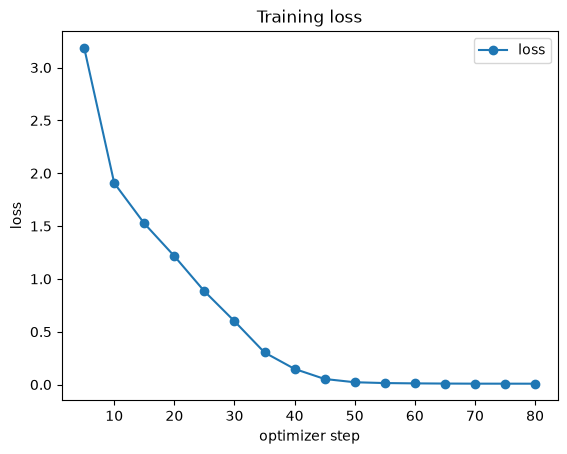

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

loss_rows = [
    {"step": row["step"], "loss": row["loss"]}
    for row in trainer.state.log_history
    if "loss" in row and "step" in row
]

loss_df = pd.DataFrame(loss_rows)
display(loss_df.tail(20))

if len(loss_df) > 0:
    ax = loss_df.plot(x="step", y="loss", marker="o", title="Training loss")
    ax.set_xlabel("optimizer step")
    ax.set_ylabel("loss")
    plt.show()


## 11. After: 파인튜닝 후 응답 비교

학습 전에 저장해 둔 `before_answers`와 학습 후 `ask()` 결과를 나란히 출력합니다. 학습 데이터에 없던 직무·기술 조합에서도 정확히 3개의 질문을 생성하는지, 지원자의 경험에 나온 기술을 구체적으로 활용하는지, 무관한 기술을 임의로 끌어오지 않는지 확인합니다.


In [17]:
print("=" * 60)
print("AI 기술면접 질문 Before/After 비교")
print("=" * 60)
for q in test_questions:
    after_ans = ask(q)
    print(f"\nQ: {q}")
    print(f"[Before] {before_answers[q]}")
    print(f"[After ] {after_ans}")
    print("-" * 50)


AI 기술면접 질문 Before/After 비교

Q: 지원자의 경험을 바탕으로 실제 역량을 검증할 수 있는 심층 기술면접 질문 3개를 만들어라.
직무: RAG 개발자
경험: LlamaIndex와 Weaviate로 문서 검색 시스템을 구축하고 cross-encoder reranker를 적용했다.
[Before] 다음은 **RAG(Relevant Article Generation)** 개발자가 갖는 실질적인 역량 검증을 위한 **심층 기술퀄리티 면접 질문** 3가지입니다. 각 질문은 지원자의 **기술적 이해도**, **실제 프로젝트 경험**, **문제 해결 능력** 등을 평가합니다.

---

### 🧠 1. **문서 검색 및 레이어링 기술의 응용 사례**

> **질문**:  
> "LlamaIndex를 사용하여 문서 검索 시스 tem을 구현했을 때, 어떤 방식으로 문서의 관련성을 판단하고, 이를 바탕에 렌더링된 답변을 생성하는 과정을 설명해 주세요?"

**검증 포인트**:  
- 문서 검토 및 관련성 판단 방법 (예: TF-IDF, BM25, Vector Similarity 등)  
- RAG에서 중요한 단계인 **"문서 렛레이팅"** 또는 **"cross-encoder re-rank"**의 적용 여부  
- 답변 생성 시의 **context-awareness** 및 **relevance filtering** 기법  

---

### ⚙️ 2. **Cross-Encoder Re-Ranking의 효과 및 적용 사례 설명**

> 질문:  
> "**cross-encode reranker**"를 적용한 시스 테에서 가장 큰 성과나 혜택을 누렸던 부분은 무엇인지, 어떻게 적용했고, 결과적으로 어떤 변화가 있었는지 설명해주세요?

**검验 포인ты**:  
– Cross-Encoder의 활용 범위 및 목적  
– Reranking 전후의 검색 성능 비교  
– 실제 데이터셋에서의 성능 측정 방법 (e.g., MRR, MAP, F1 등)  

---

#### 예

## 12. LoRA 어댑터 저장

학습한 어댑터와 tokenizer를 저장합니다. QLoRA와 저장 경로를 구분합니다.


In [18]:
ADAPTER_DIR = "./lora_adapters/sample_ai_interview"
model.save_pretrained(ADAPTER_DIR)
tokenizer.save_pretrained(ADAPTER_DIR)
print(f"LoRA 어댑터 저장 완료: {ADAPTER_DIR}")


LoRA 어댑터 저장 완료: ./lora_adapters/sample_ai_interview


## 정리

이 노트북에서 확인한 내용은 다음과 같습니다.

- 양자화 없이 `Qwen/Qwen3-1.7B`를 bf16으로 로드했습니다.
- 원본 모델 전체를 학습하지 않고 LoRA 어댑터만 학습했습니다.
- `instruction` / `input` / `output` 데이터를 `prompt` / `completion` 학습 형식으로 변환했습니다.
- `completion_only_loss=True`를 사용해 모범 면접 질문 부분에만 loss를 계산했습니다.
- 학습 데이터와 직접 겹치지 않는 지원자 사례로 파인튜닝 전/후 질문의 구체성과 형식을 비교했습니다.
- 최종 산출물로 AI 기술면접 질문 생성용 LoRA 어댑터를 저장했습니다.

다음 단계로는 저장된 어댑터를 다시 불러오거나, base model과 병합한 뒤 Ollama 같은 로컬 실행 환경에 배포할 수 있습니다.
